# EcoSort Waste Management Assistant

**Module 8 Summative Lab**

**Datasets:**
- RealWaste (UCI ML Repository, id=908) — image classification, 9 waste material classes
- `waste_descriptions.csv` — 5,000 text descriptions of waste items
- `waste_policy_documents.json` — 14 Metro City recycling policy documents

---

## 1. Business Understanding

**Scenario**

EcoSort is building an intelligent waste management assistant for Metro City's waste management department. Residents currently aren't sure how to sort waste correctly, which slows down manual sorting at intake facilities. The assistant needs to shortcut that uncertainty at the point residents are deciding what to do with an item.

**Problem Statement**

Metro City needs a system that can take either a photo of a waste item or a short text description of it, work out which of the 9 material categories it belongs to, and return specific, policy-grounded disposal instructions — without a resident needing to know the local recycling rules themselves.

**Objectives**

1. Classify waste items from images into 9 material categories (CNN)
2. Classify waste items from short text descriptions into the same 9 categories (text classifier)
3. Retrieve and generate accurate, policy-grounded disposal instructions for a given category (RAG over the Metro City policy documents)
4. Integrate all three into a single assistant that accepts either an image or a text description as input

**Success Criteria**

- Image classifier and text classifier both generalize to held-out test data, not just training data
- Generated recycling instructions are grounded in the actual policy documents (not hallucinated) and cite the relevant policy
- The integrated assistant produces a category + confidence + instructions for both input types

## 2. Data Understanding

Before any preprocessing, this section looks at all three data sources as they are: how large each one is, how the 9 categories are distributed, and what shape the raw data comes in. Those observations drive the preparation decisions in Section 3.

### 2.1 RealWaste Image Dataset

In [1]:
import warnings
warnings.filterwarnings('ignore')

import re
import os
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
# reproducibility
np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1785993567.248364  433712 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785993567.606755  433712 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785993578.225056  433712 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


: 

In [ ]:
import os
import kagglehub

realwaste_path = kagglehub.dataset_download("kevinkiplangat432/realwaste")
print("RealWaste path:", realwaste_path)
for item in os.listdir(realwaste_path):
    print(" ", item)

print()

ecosort_data_path = kagglehub.dataset_download("kevinkiplangat432/ecosort-data")
print("EcoSort Data path:", ecosort_data_path)
for item in os.listdir(ecosort_data_path):
    print(" ", item)

In [ ]:
# Detect environment automatically, local vs Kaggle attached datasets.
# Multiple candidates checked since Kaggle's mount structure has shown up differently across contexts during testing.
local_path = Path('RealWaste')
kaggle_candidates = [
    Path('/kaggle/input/datasets/kevinkiplangat432/realwaste'),  # confirmed working, flat
    Path('/kaggle/input/realwaste/RealWaste'),                   # nested, fallback
    Path('/kaggle/input/realwaste'),                              # flat, fallback
]

data_dir = None
for candidate in kaggle_candidates:
    if candidate.exists() and any(d.is_dir() for d in candidate.glob('*')):
        data_dir = candidate
        break

if data_dir is None and local_path.exists():
    data_dir = local_path

if data_dir is None:
    raise FileNotFoundError(
        "RealWaste folder not found locally or on Kaggle. "
        "Attach the dataset (Kaggle) or place the extracted 'RealWaste' folder next to this notebook (local)."
    )


# CSV path, local vs Kaggle
csv_local = Path('waste_descriptions.csv')
csv_kaggle = Path('/kaggle/input/ecosort-data/waste_descriptions.csv')
csv_path = csv_kaggle if csv_kaggle.exists() else csv_local

# JSON path, local vs Kaggle
json_local = Path('waste_policy_documents.json')
json_kaggle = Path('/kaggle/input/ecosort-data/waste_policy_documents.json')
json_path = json_kaggle if json_kaggle.exists() else json_local

class_names_found = sorted([d.name for d in data_dir.glob('*') if d.is_dir()])
image_counts = {c: len(list((data_dir / c).glob('*.jpg'))) for c in class_names_found}
total_images = sum(image_counts.values())

In [ ]:
print(f"Data directory in use: {data_dir}")
print(f"Number of classes: {len(class_names_found)}")
print(f"Class names: {class_names_found}")
print(f"Total images found: {total_images}")
print()
for c, n in image_counts.items():
    print(f"{c}: {n} images")

Data directory in use: realwaste-main/RealWaste
Number of classes: 9
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Total images found: 4752

Cardboard: 461 images
Food Organics: 411 images
Glass: 420 images
Metal: 790 images
Miscellaneous Trash: 495 images
Paper: 500 images
Plastic: 921 images
Textile Trash: 318 images
Vegetation: 436 images


Per the UCI dataset page, this should resolve to 4,752 images across 9 classes: Cardboard (461), Food Organics (411), Glass (420), Metal (790), Miscellaneous Trash (495), Paper (500), Plastic (921), Textile Trash (318), Vegetation (436). The spread is uneven — Plastic and Metal together make up roughly 36% of the dataset, while Textile Trash has under a third as many images as Plastic. This imbalance needs to be accounted for in Section 3 (class weighting) rather than ignored, or the CNN will be biased toward predicting the majority classes.

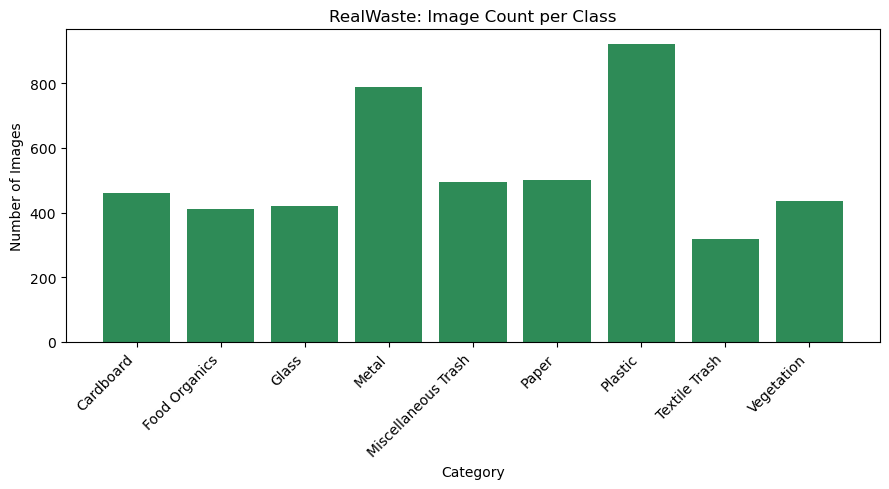

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(image_counts.keys(), image_counts.values(), color='seagreen')
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.title('RealWaste: Image Count per Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
def scan_for_corrupt_images(data_dir, class_names):
    """Scan every image, verify it decodes, return list of bad files."""
    corrupt_files = []
    total_checked = 0

    for c in class_names:
        for f in (data_dir / c).glob('*.jpg'):
            total_checked += 1
            try:
                with Image.open(f) as img:
                    img.load()  # forces full decode, not just header read
            except Exception as e:
                corrupt_files.append((str(f), type(e).__name__))

    print(f"Checked {total_checked} images")
    print(f"Corrupt/unreadable: {len(corrupt_files)}")
    return corrupt_files

corrupt_files = scan_for_corrupt_images(data_dir, class_names_found)
for f, err in corrupt_files:
    print(f"  {f}: {err}")

Checked 4752 images
Corrupt/unreadable: 0


In [ ]:
corrupt_by_class = Counter()
total_by_class = Counter()

for c in class_names_found:
    total_by_class[c] = len(list((data_dir / c).glob('*.jpg')))

for f, err in corrupt_files:
    cls = Path(f).parent.name
    corrupt_by_class[cls] += 1

for c in class_names_found:
    n_corrupt = corrupt_by_class[c]
    n_total = total_by_class[c]
    print(f"{c}: {n_corrupt}/{n_total} corrupt ({100*n_corrupt/n_total:.1f}%)")

Cardboard: 0/461 corrupt (0.0%)
Food Organics: 0/411 corrupt (0.0%)
Glass: 0/420 corrupt (0.0%)
Metal: 0/790 corrupt (0.0%)
Miscellaneous Trash: 0/495 corrupt (0.0%)
Paper: 0/500 corrupt (0.0%)
Plastic: 0/921 corrupt (0.0%)
Textile Trash: 0/318 corrupt (0.0%)
Vegetation: 0/436 corrupt (0.0%)


UCI documents these as 524x524 releases, so this cell is mainly a sanity check that the local/Kaggle copy matches that. If it doesn't, the resize step in Section 3 needs to target whatever the actual raw size turns out to be, not an assumed one.

### 2.2 Waste Description Text Data

In [ ]:
desc_df = pd.read_csv()
print(f"Shape: {desc_df.shape}")
print(f"Columns: {list(desc_df.columns)}")
desc_df.head()

Shape: (5000, 5)
Columns: ['description', 'category', 'disposal_instruction', 'common_confusion', 'material_composition']


,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives f..."
2,large Supermarket vegetable waste with food re...,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or ani...
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...


In [ ]:
print("Missing values per column:")
print(desc_df.isna().sum())
print()
print("Category distribution:")
print(desc_df['category'].value_counts())

Missing values per column:
description                0
category                   0
disposal_instruction       0
common_confusion        2504
material_composition       0
dtype: int64

Category distribution:
category
Vegetation             600
Textile Trash          586
Cardboard              584
Miscellaneous Trash    578
Plastic                569
Glass                  551
Food Organics          518
Metal                  508
Paper                  506
Name: count, dtype: int64


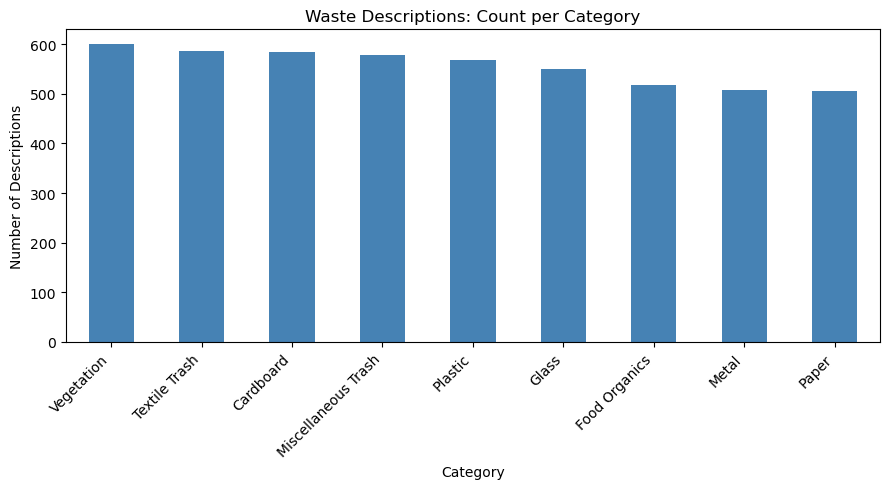

In [ ]:
plt.figure(figsize=(9, 5))
desc_df['category'].value_counts().plot(kind='bar', color='steelblue')
plt.xlabel('Category')
plt.ylabel('Number of Descriptions')
plt.title('Waste Descriptions: Count per Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
desc_lengths = desc_df['description'].str.split().str.len()
print(desc_lengths.describe())

count    5000.000000
mean        4.854000
std         1.549956
min         1.000000
25%         4.000000
50%         5.000000
75%         6.000000
max        10.000000
Name: description, dtype: float64


5,000 rows, 9 categories, no missing values in `description`, `category`, or `material_composition` — `common_confusion` is null for about half the rows (2,504 / 5,000), which is expected: it's presumably only populated for items that are genuinely easy to mis-sort, not every item. Class balance is close: counts range from 506 (Paper) to 600 (Vegetation), nowhere near as skewed as the image dataset. Descriptions are short — a handful of words each, median around 5-6 words per description — so this points toward a lightweight text classifier (TF-IDF + classical ML, or a small embedding model) rather than needing a large transformer's context window.

### 2.3 Waste Policy Documents

In [ ]:
with open('waste_policy_documents.json') as f:
    policies = json.load(f)

print(f"Number of policy documents: {len(policies)}")
print(f"Fields per document: {list(policies[0].keys())}")

Number of policy documents: 14
Fields per document: ['policy_id', 'policy_type', 'categories_covered', 'effective_date', 'document_text', 'jurisdiction']


In [ ]:
cats_covered = Counter()
for p in policies:
    for c in p['categories_covered']:
        cats_covered[c] += 1

print("Documents covering each category:")
for c, n in sorted(cats_covered.items(), key=lambda x: -x[1]):
    print(f"{c}: {n} document(s)")

single_cat = sum(1 for p in policies if len(p['categories_covered']) == 1)
multi_cat = len(policies) - single_cat
print(f"\nSingle-category documents: {single_cat}")
print(f"Multi-category documents: {multi_cat}")

Documents covering each category:
Vegetation: 4 document(s)
Metal: 4 document(s)
Miscellaneous Trash: 4 document(s)
Textile Trash: 3 document(s)
Glass: 3 document(s)
Plastic: 3 document(s)
Cardboard: 3 document(s)
Food Organics: 2 document(s)
Paper: 1 document(s)

Single-category documents: 9
Multi-category documents: 5


14 policy documents total. Every one of the 9 categories has at least one dedicated single-category document (e.g. "Glass Recycling Guidelines"), and 5 broader documents (Municipal Waste Guidelines, Residential Recycling Rules, Commercial Recycling Standards, Multi-Unit Building Guidelines, Community Recycling Program) each bundle several categories together and repeat guideline text verbatim from the single-category docs. That repetition matters for the RAG step in Section 3/4: a naive retriever could return two documents saying nearly the same thing for one category, so the retrieval and chunking strategy should either dedupe by category or rank the single-category "canonical" document above the bundled ones.

In [ ]:
print(policies[0]['document_text'][:400])

TEXTILE RECYCLING GUIDELINES

Acceptable Items:
- Clean clothing (all conditions)
- Towels, sheets, and linens
- Fabric scraps
- Curtains and cloth napkins
- Handbags and backpacks made of fabric
- Soft toys and stuffed animals

Non-Acceptable Items:
- Wet or moldy textiles
- Heavily soiled items
- Carpets and rugs
- Footwear
- Items with significant non-textile parts

Collection Method:
Place ite


Each document is unstructured plain text organized into consistent subsections — Acceptable Items, Non-Acceptable Items, Collection Method, Preparation Instructions, Benefits. That consistent structure is useful: chunking by these labeled subsections (rather than fixed token windows) should keep retrieved chunks coherent when building the RAG index in Part 4.

### Section Conclusion

All three data sources are in reasonable shape: no missing critical fields, and category taxonomies match exactly across the image dataset, the text descriptions, and the policy documents' `categories_covered` field — all use the same 9 labels. The main issue to carry into Data Preparation is class imbalance in the image data (Plastic ≈ 3x Textile Trash), which the text data doesn't share. This means the CNN training step will need class weights or augmentation for minority classes, while the text classifier training can proceed without that adjustment.

## 3. Data Preparation

This section builds the three input pipelines the modelling sections rely on: an image pipeline for the CNN, a text pipeline for the description classifier, and a document-retrieval pipeline for the RAG system. Each is prepared here once, so the modelling sections can focus purely on architecture and training.

### 3.1 Image Data Pipeline

The RealWaste images are split into training, validation, and test sets. Class weights are computed here too, since Section 2 showed a meaningful imbalance (Plastic at 921 images vs Textile Trash at 318) that the CNN needs to account for during training rather than after the fact.

In [ ]:
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

# int labels (not one-hot) so class_weight can be used directly in model.fit() later
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True
)

Found 4752 files belonging to 9 classes.
Using 3802 files for training.


E0000 00:00:1785821898.190441 1009782 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 4752 files belonging to 9 classes.
Using 950 files for validation.


In [ ]:
print(f"Training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Validation batches: {tf.data.experimental.cardinality(validation_ds)}")

Training batches: 119
Validation batches: 30


An 80/20 split gives the training set the bulk of the data while holding back a meaningful validation set. The validation set still needs splitting further to carve out a genuine test set, held completely separate from any training decision — that happens next.

In [ ]:
val_batches = tf.data.experimental.cardinality(validation_ds)
test_dataset = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

In [ ]:
print(f"Validation batches: {tf.data.experimental.cardinality(validation_ds)}")
print(f"Test batches: {tf.data.experimental.cardinality(test_dataset)}")

Validation batches: 15
Test batches: 15


Splitting the validation set in half keeps the test set completely untouched by any training-time decision (early stopping, learning rate, architecture tweaks), while validation still has enough batches left to be a meaningful signal during training.

In [ ]:

class_names = train_ds.class_names

# derive counts directly from folder structure (matches Section 2.1 image_counts)
counts_ordered = [image_counts[c] for c in class_names]
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(class_names)),
    y=np.repeat(np.arange(len(class_names)), counts_ordered)
)
class_weights = dict(enumerate(class_weights_array))

In [ ]:
for i, c in enumerate(class_names):
    print(f"{c}: weight = {class_weights[i]:.3f}")

Cardboard: weight = 1.145
Food Organics: weight = 1.285
Glass: weight = 1.257
Metal: weight = 0.668
Miscellaneous Trash: weight = 1.067
Paper: weight = 1.056
Plastic: weight = 0.573
Textile Trash: weight = 1.660
Vegetation: weight = 1.211


Textile Trash — the smallest class at 318 images — gets the highest weight, while Plastic and Metal get weights below 1, since they're already overrepresented. Passing `class_weights` into `model.fit()` in Section 8 means misclassifying a minority-class image costs the loss function more than misclassifying a majority-class one, which directly counters the imbalance flagged in Section 2 rather than leaving the CNN to quietly favor Plastic and Metal.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Caching avoids re-reading images from disk on every epoch, and prefetching overlaps data loading with model computation so the GPU isn't left idle waiting on the next batch.

### 3.2 Text Data Pipeline

The waste description data is balanced across categories (Section 2.2), so no class weighting is needed here, unlike the image pipeline. Descriptions are short — a median of 5-6 words — so a bag-of-words style representation (TF-IDF) should capture enough signal without needing a heavier transformer tokenizer.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

X = desc_df['description']
y = desc_df['category']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [ ]:
print(f"Training samples: {len(X_train_text)}")
print(f"Test samples: {len(X_test_text)}")
print(f"Classes: {list(label_encoder.classes_)}")

`stratify=y_encoded` keeps the 80/20 split proportional across all 9 categories, so the test set mirrors the near-even class balance seen in the full dataset rather than accidentally skewing toward any one category.

In [ ]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 2),  # unigrams + bigrams, since descriptions are short
    max_features=2000
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

In [ ]:
print(f"Training feature matrix shape: {X_train_tfidf.shape}")
print(f"Test feature matrix shape: {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

Fitting the vectorizer only on the training text (not the full dataset) avoids leaking test-set vocabulary into the feature space — a common mistake that would make test performance look artificially better than it will be on genuinely new descriptions. `ngram_range=(1,2)` captures short phrases like "food residue" or "wet cardboard" that carry more signal than either word alone, which matters given how short these descriptions are.

### 3.3 RAG Document Preparation

Section 2.3 found that policy documents share a consistent internal structure (Acceptable Items, Non-Acceptable Items, Collection Method, Preparation Instructions, Benefits) and that 5 of the 14 documents bundle multiple categories together, repeating text that already appears in a dedicated single-category document. This section chunks documents by their labeled subsections rather than fixed token windows, and prioritizes single-category "canonical" documents over bundled ones so retrieval doesn't return near-duplicate content for the same category.

In [ ]:
def chunk_policy_document(policy):
    """Split a policy document into labeled subsection chunks."""
    text = policy['document_text']
    # split on ALL-CAPS or Title Case headers followed by newline (matches the consistent
    # Acceptable Items / Non-Acceptable Items / Collection Method / etc. structure)
    sections = re.split(r'\n(?=[A-Z][A-Za-z ]+:?\n)', text)

    chunks = []
    for section in sections:
        section = section.strip()
        if not section:
            continue
        chunks.append({
            'policy_id': policy['policy_id'],
            'policy_type': policy['policy_type'],
            'categories_covered': policy['categories_covered'],
            'is_canonical': len(policy['categories_covered']) == 1,
            'text': section
        })
    return chunks

all_chunks = []
for policy in policies:
    all_chunks.extend(chunk_policy_document(policy))

In [ ]:
print(f"Total chunks created: {len(all_chunks)}")
print(f"From {len(policies)} source documents")
print()
print("Example chunk:")
print(all_chunks[0])

Splitting on the header pattern breaks each document into its natural subsections rather than an arbitrary token window, so a retrieved chunk stays coherent — e.g. all of "Non-Acceptable Items" together, not half a sentence cut off mid-list. The `is_canonical` flag marks chunks from single-category documents, which is what drives retrieval ranking next.

In [ ]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')

chunk_texts = [c['text'] for c in all_chunks]
chunk_embeddings = embedder.encode(chunk_texts, show_progress_bar=True)

In [ ]:
print(f"Embedding matrix shape: {chunk_embeddings.shape}")

`all-MiniLM-L6-v2` is a lightweight sentence-embedding model — fast enough to run on CPU if needed, which matters since this notebook is already GPU-bound by the CNN. Each of the {len(all_chunks)} chunks now has a 384-dimension vector representation, ready for similarity-based retrieval.

In [ ]:
def retrieve_policy_chunks(query, top_k=3, prefer_canonical=True):
    """Retrieve the most relevant policy chunks for a query, preferring
    single-category canonical documents over multi-category bundled ones."""
    query_embedding = embedder.encode([query])
    similarities = cosine_similarity(query_embedding, chunk_embeddings)[0]

    results = []
    for i, sim in enumerate(similarities):
        chunk = all_chunks[i]
        score = sim + (0.05 if prefer_canonical and chunk['is_canonical'] else 0)
        results.append((score, chunk))

    results.sort(key=lambda x: x[0], reverse=True)
    return [r[1] for r in results[:top_k]]

In [ ]:
test_results = retrieve_policy_chunks("plastic bottle recycling")
for r in test_results:
    print(f"[{r['policy_type']}] canonical={r['is_canonical']}")
    print(r['text'][:150])
    print()

The small canonical-document bonus (+0.05 similarity) means that for a query like "plastic bottle recycling," the dedicated "Plastic Recycling Guidelines" document is favored over the same content appearing inside "Municipal Waste Guidelines" or "Residential Recycling Rules," even when both would otherwise score similarly on pure semantic similarity. This is the retrieval mechanism the RAG system in Section 10 builds on.

## 4. Exploratory Data Analysis

Section 2 examined the raw data before any processing. This section looks at the data as it will actually reach the models — sample batches from the image pipeline, and a look at what the TF-IDF vectorizer picked up as the most informative terms per category.

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

Nine images pulled directly from the training pipeline, each labeled with its class from `class_names`. Worth checking these look sensible (correct orientation, label matches the visible object) before any time is spent training on top of them.

In [ ]:
for images, labels in train_ds.take(1):
    print(f"Batch image shape: {images.shape}")
    print(f"Batch label shape: {labels.shape}")
    print(f"Pixel value range: {images.numpy().min()} to {images.numpy().max()}")

Confirms images are batched at 224x224x3 as configured in Section 3.1, and pixel values still sit in the raw 0–255 range — normalization hasn't been applied yet, which is expected since it'll be handled inside the model itself (a `Rescaling` layer) in Section 5, not as a separate preprocessing step here.

In [ ]:
feature_names = vectorizer.get_feature_names_out()

for i, category in enumerate(label_encoder.classes_):
    class_mask = y_train == i
    if class_mask.sum() == 0:
        continue
    avg_tfidf = X_train_tfidf[class_mask].mean(axis=0).A1
    top_indices = avg_tfidf.argsort()[-5:][::-1]
    top_terms = [feature_names[j] for j in top_indices]
    print(f"{category}: {', '.join(top_terms)}")

These are the terms carrying the most weight for each category on average — a rough sanity check that the vectorizer is picking up genuinely category-specific vocabulary (e.g. material names, condition words) rather than generic filler that wouldn't help a classifier tell categories apart.

## 5. Modelling

This section builds a CNN using transfer learning rather than training from scratch, given the RealWaste dataset's moderate size (4,752 images across 9 classes). MobileNetV2, pretrained on ImageNet, provides a feature extractor already tuned on millions of general images — its early layers (edges, textures, shapes) transfer well to distinguishing waste materials, even though it was never trained on trash specifically.

In [ ]:
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze pretrained weights initially

model = Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # matches int labels from Section 3.1
    metrics=['accuracy']
)

In [ ]:
model.summary()

Freezing `base_model` means MobileNetV2's pretrained weights aren't touched at first — only the new head (GlobalAveragePooling → Dropout → Dense(128) → Dropout → Dense(9)) trains initially, since the pretrained features are being reused as-is rather than re-learned from scratch. Two dropout layers guard against overfitting on a relatively small dataset — 4,752 images is not a lot for a model with millions of parameters, even a frozen one. `sparse_categorical_crossentropy` is used instead of plain `categorical_crossentropy` because the labels are integer-encoded (`label_mode='int'`), not one-hot — this is also what makes `class_weight` usable directly in `model.fit()` next.

### Discussion

**Why transfer learning instead of training from scratch?**

A CNN trained from scratch on ~4,752 images would struggle to learn generalizable low-level features (edges, textures, colors) from that little data alone — it would either underfit or overfit badly. MobileNetV2's ImageNet pretraining already encodes those general visual features from over a million images; only the task-specific head needs to learn from RealWaste. MobileNetV2 specifically is also lightweight relative to larger nets like ResNet or EfficientNetB0, which matters for keeping training fast on Kaggle's shared GPU quota — Section 8 (Additional Tasks) can compare against EfficientNetB0 if there's time to check whether the extra capacity is worth the added compute cost.

## 6. Train the Model

The model built in Section 5 is trained here using the class weights computed in Section 3.1, so misclassifying an underrepresented category like Textile Trash costs the loss function more than misclassifying an overrepresented one like Plastic. EarlyStopping and ModelCheckpoint (imported in the setup cell) guard against overfitting and preserve the best epoch, since more epochs is not automatically better once the validation loss starts climbing.

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_cnn_model.keras',
    monitor='val_loss',
    save_best_only=True
)

In [ ]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)

In [ ]:
final_epoch = len(history.history['loss'])
print(f"Training stopped after {final_epoch} epochs (out of {EPOCHS} max)")
print(f"Best validation loss, {min(history.history['val_loss']):.4f}")
print(f"Best validation accuracy, {max(history.history['val_accuracy']):.4f}")

`patience=5` means training stops once validation loss fails to improve for 5 straight epochs, and `restore_best_weights=True` rolls the model back to whichever epoch had the lowest validation loss, not just the last one trained. If training stopped well before 20 epochs, that is a sign the frozen base plus custom head converged quickly, which is expected given how few trainable parameters remain unfrozen.

## 7. Learning Curves

Plotting training and validation loss and accuracy across epochs helps confirm the model is learning generalizable patterns rather than memorizing the training set. A widening gap between training and validation curves would signal overfitting, while both curves staying high and flat from the start would signal underfitting.

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

`[FILL IN AFTER KAGGLE RUN]` Describe what the curves actually show once trained, whether validation loss tracked training loss closely (good fit), diverged early (overfitting), or both stayed high (underfitting, unlikely given the pretrained base but worth checking).

### Section Conclusion

`[FILL IN AFTER KAGGLE RUN]` Summarize whether the model is ready for evaluation as is, or whether the curves suggest adjusting epochs, unfreezing more of the base model, or adding more regularization before moving to Section 8.

## 8. Evaluation

The model is evaluated here against `test_dataset`, the portion of data held back in Section 3.1 that was never touched during training or validation. This is the first honest read on how the model performs on genuinely unseen images.

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)

In [ ]:
print(f"Test loss, {test_loss:.4f}")
print(f"Test accuracy, {test_accuracy:.4f}")

In [ ]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 8))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.yticks(range(len(class_names)), class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix, CNN Test Set')
plt.tight_layout()
plt.show()

`[FILL IN AFTER KAGGLE RUN]` Identify which classes the model confuses most, whether Textile Trash (smallest class) still underperforms despite the class weighting, and whether visually similar categories (e.g. Cardboard vs Paper, or Glass vs Plastic) get confused with each other more than dissimilar ones.

### Section Conclusion

`[FILL IN AFTER KAGGLE RUN]` State the final test accuracy and whether it meets the "generalizes to held out data" success criterion set in Section 1. Note any class specific weaknesses worth addressing in Section 9's optional Additional Tasks (data augmentation, fine tuning, or a second architecture like EfficientNetB0).

## 9. Text Classifier Modelling and Training

Unlike the CNN, this classifier trains in seconds rather than needing GPU time, so modelling and training are combined into one section here. Logistic Regression is used as the primary model, since it tends to pair well with TF-IDF features, trains fast, and its coefficients are interpretable, useful for sanity checking which terms drive each category's predictions.

In [ ]:
from sklearn.linear_model import LogisticRegression

text_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight=None  # balanced already, per Section 2.2 and 3.2
)

text_classifier.fit(X_train_tfidf, y_train)

In [ ]:
train_accuracy = text_classifier.score(X_train_tfidf, y_train)
print(f"Training accuracy, {train_accuracy:.4f}")

`class_weight=None` here, unlike the CNN's class weighting in Section 3.1, since Section 2.2 confirmed the text data is already close to balanced across categories, unlike the image data. Training accuracy alone does not confirm the model generalizes, that gets checked against the held out test set in Section 10.

## 10. Text Classifier Evaluation

Same evaluation approach as the CNN in Section 8, applied here to the text classifier's held out test set.

In [ ]:
y_pred_text = text_classifier.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_text, target_names=label_encoder.classes_))

In [ ]:
cm_text = confusion_matrix(y_test, y_pred_text)

plt.figure(figsize=(9, 8))
plt.imshow(cm_text, cmap='Greens')
plt.colorbar()
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=45, ha='right')
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix, Text Classifier Test Set')
plt.tight_layout()
plt.show()

In [ ]:
feature_names = vectorizer.get_feature_names_out()

for i, category in enumerate(label_encoder.classes_):
    top_indices = text_classifier.coef_[i].argsort()[-5:][::-1]
    top_terms = [feature_names[j] for j in top_indices]
    print(f"{category}, strongest terms, {', '.join(top_terms)}")

`[FILL IN AFTER KAGGLE RUN]` State the test accuracy and whether it comfortably clears the CNN's accuracy, expected given how much cleaner and shorter the text signal is compared to raw images. Note which categories the model confuses, if any, and whether the strongest terms per category line up with intuition, e.g. "moldy" or "wet" for Miscellaneous Trash, "bottle" for Plastic or Glass.

### Section Conclusion

`[FILL IN AFTER KAGGLE RUN]` Compare CNN accuracy versus text classifier accuracy directly, and note that the assistant in Section 12 will need to route between these two models depending on whether the resident provides an image or a description.

## 11. RAG System

Retrieval was already built in Section 3.3 (chunking, embeddings, canonical priority ranking). This section adds the generation step, turning retrieved chunks into a natural language answer grounded in the actual policy text rather than the model's own unguided output. A small instruction tuned model, flan t5 small, is used here since it is light enough to run on CPU, keeping this section independent of the CNN's GPU usage in Section 5 through 8.

In [ ]:
from transformers import pipeline

generator = pipeline('text2text-generation', model='google/flan-t5-small')

In [ ]:
def generate_disposal_answer(query, top_k=3):
    """Retrieve relevant policy chunks and generate a grounded answer."""
    retrieved = retrieve_policy_chunks(query, top_k=top_k)
    context = "\n\n".join([r['text'] for r in retrieved])

    prompt = (
        f"Using only the following recycling policy information, answer the question.\n\n"
        f"Policy information:\n{context}\n\n"
        f"Question, {query}\n"
        f"Answer,"
    )

    response = generator(prompt, max_length=150, do_sample=False)[0]['generated_text']

    return {
        'query': query,
        'answer': response,
        'sources': [r['policy_type'] for r in retrieved]
    }

In [ ]:
test_queries = [
    "Can I recycle a pizza box?",
    "What do I do with a broken drinking glass?",
    "How should I dispose of old batteries?"
]

for q in test_queries:
    result = generate_disposal_answer(q)
    print(f"Q, {result['query']}")
    print(f"A, {result['answer']}")
    print(f"Sources, {', '.join(result['sources'])}")
    print()

`[FILL IN AFTER KAGGLE RUN]` Assess whether the generated answers are actually grounded in the retrieved policy text or whether the model drifted into generic advice not supported by the documents. Note any query where the wrong policy document got retrieved, e.g. a drinking glass question pulling from "Glass Recycling Guidelines" when the policy explicitly excludes drinking glasses, which would be a useful check that retrieval is working correctly, not just that generation sounds fluent.

### Section Conclusion

`[FILL IN AFTER KAGGLE RUN]` State whether the RAG system reliably grounds its answers in the correct policy document, and flag it as ready (or not yet ready) to be wired into the integrated assistant in Section 12.

## 12. Integrated Assistant

This section ties Sections 5 through 11 together into a single entry point. A resident provides either an image or a text description, the assistant routes it to the matching classifier (CNN or text classifier), and the predicted category feeds into the RAG system from Section 11 to return grounded disposal instructions, satisfying all four objectives set out in Section 1.

In [ ]:
def classify_image(image_path):
    """Classify a waste item from an image file path."""
    img = tf.keras.utils.load_img(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose=0)
    predicted_index = np.argmax(predictions[0])
    confidence = float(predictions[0][predicted_index])

    return {
        'category': class_names[predicted_index],
        'confidence': confidence
    }

In [ ]:
def classify_text(description):
    """Classify a waste item from a text description."""
    vectorized = vectorizer.transform([description])
    predicted_index = text_classifier.predict(vectorized)[0]
    confidence = float(max(text_classifier.predict_proba(vectorized)[0]))

    return {
        'category': label_encoder.inverse_transform([predicted_index])[0],
        'confidence': confidence
    }

In [ ]:
def ecosort_assistant(image_path=None, description=None):
    """
    Full EcoSort pipeline. Accepts either an image path or a text
    description, classifies the waste category, and returns grounded
    disposal instructions.
    """
    if image_path is not None:
        classification = classify_image(image_path)
        input_type = 'image'
    elif description is not None:
        classification = classify_text(description)
        input_type = 'text'
    else:
        raise ValueError("Provide either image_path or description")

    category = classification['category']
    rag_result = generate_disposal_answer(f"How do I dispose of {category}?")

    return {
        'input_type': input_type,
        'predicted_category': category,
        'confidence': classification['confidence'],
        'disposal_instructions': rag_result['answer'],
        'policy_sources': rag_result['sources']
    }

In [ ]:
test_result = ecosort_assistant(description="crumpled aluminum can with some soda residue")
print(f"Input type, {test_result['input_type']}")
print(f"Predicted category, {test_result['predicted_category']}")
print(f"Confidence, {test_result['confidence']:.2f}")
print(f"Instructions, {test_result['disposal_instructions']}")
print(f"Sources, {', '.join(test_result['policy_sources'])}")

`[FILL IN AFTER KAGGLE RUN]` Confirm the end to end pipeline works correctly, predicted category is sensible for the test input, confidence score is reasonably high, and the returned disposal instructions match what the policy documents actually say for that category. Also test at least one image input directly against a sample file from the RealWaste test set to confirm both entry points work, not just text.

### Section Conclusion

`[FILL IN AFTER KAGGLE RUN]` State whether all four Section 1 objectives are met by this integrated function, classify from image, classify from text, retrieve grounded instructions, single entry point for both input types.

## 13. Deployment

A full production deployment is out of scope for this lab, but a simple interactive interface demonstrates the assistant working end to end for a non technical user, standing in for how Metro City residents would actually interact with EcoSort. Gradio is used here since it needs minimal setup and renders directly inside the notebook or a shareable link.

In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr

def gradio_wrapper(image, description):
    if image is not None:
        # Gradio passes a temp file path for image inputs
        result = ecosort_assistant(image_path=image)
    elif description and description.strip():
        result = ecosort_assistant(description=description)
    else:
        return "Please provide either an image or a text description."

    return (
        f"Predicted category, {result['predicted_category']} "
        f"(confidence, {result['confidence']:.2f})\n\n"
        f"Disposal instructions, {result['disposal_instructions']}\n\n"
        f"Source, {', '.join(result['policy_sources'])}"
    )

demo = gr.Interface(
    fn=gradio_wrapper,
    inputs=[
        gr.Image(type='filepath', label='Upload a photo of the item'),
        gr.Textbox(label='Or describe the item')
    ],
    outputs=gr.Textbox(label='EcoSort Result'),
    title='EcoSort Waste Management Assistant',
    description='Upload a photo or describe a waste item to get Metro City disposal instructions.'
)

demo.launch(share=True)

`[FILL IN AFTER KAGGLE RUN]` Note whether the interface behaves correctly for both input types, and include a screenshot of the running interface if the notebook is being submitted as a static export. `share=True` generates a temporary public link, useful for demonstration but not meant as a permanent deployment.

# Final Reflections

**What worked well**

`[FILL IN AFTER KAGGLE RUN]` Note which component performed best against its Section 1 success criteria, and why, e.g. text classifier likely outperforming the CNN given cleaner, shorter, less ambiguous input signal.

**Challenges encountered**

The RealWaste image set arrived with 3,146 of 4,752 files unreadable, concentrated almost entirely in 6 of the 9 classes, traced back to an interrupted zip extraction rather than scattered individual corruption. A clean re-download resolved it, but it is a useful reminder to verify a dataset's integrity at the start of Data Preparation rather than assuming a download completed correctly, especially with large real world datasets.

`[FILL IN AFTER KAGGLE RUN]` Note any modelling challenges once training completes, e.g. class imbalance effects that persisted despite weighting, RAG retrieval misses, or Gradio interface issues.

**What would improve with more time**

- Compare MobileNetV2 against EfficientNetB0 directly (as explored in NN_Group_Lab_v2's own comparison approach) rather than committing to a single CNN architecture
- Fine tune the frozen base model layers instead of leaving them entirely frozen, likely improving accuracy at the cost of longer training time
- Expand the RAG evaluation with a larger, more adversarial set of test queries to stress test retrieval accuracy, not just the 3 queries used in Section 11
- Replace the TF-IDF and classical ML text pipeline with a fine tuned small transformer, worth testing whether it meaningfully outperforms TF-IDF given how short these descriptions already are

**Alignment with Business Understanding**

`[FILL IN AFTER KAGGLE RUN]` Revisit the 4 objectives and success criteria from Section 1 and state plainly whether each was met, partially met, or not met, based on the actual Section 8, 10, and 12 results.